# Dataset

### Dataset 확인 

In [1]:
import pandas as pd

In [2]:
csv_file = "./data/training/illnesses.csv"

df = pd.read_csv(csv_file)

print(f"(전체 데이터 수, 전체 컬럼 수): {df.shape}")
df.head(2)

(전체 데이터 수, 전체 컬럼 수): (793, 6)


,user_input,reference,reference_video_url,persona_name,query_style,query_length
0,소아청소년과에서 수족구병에 대해 부모님들이 알아야 할 중요한 정보는 뭐에요?,"수족구병은 전염성이 매우 강한 질병으로, 급성기에는 어린이집이나 유치원에 보내지 않...",https://www.youtube.com/watch?v=omxS7s9dn-E,a compassionate pediatrician,POOR_GRAMMAR,LONG
1,일본뇌염 예방을 위해 IR3535 성분의 모기기피제를 사용하는 것이 왜 중요한가요?,IR3535 성분의 모기기피제를 사용하는 것은 일본뇌염 경보가 발령된 상황에서 모기...,https://www.youtube.com/watch?v=VNS2QM4M5jo,a pediatric medical expert,PERFECT_GRAMMAR,MEDIUM


### 허깅페이스 데이터셋으로 변환 

In [3]:
from datasets import load_dataset

In [4]:
csv_dataset = load_dataset("csv", data_files=csv_file)

Generating train split: 0 examples [00:00, ? examples/s]

In [5]:
print("CSV 데이터셋:")
print(csv_dataset)

CSV 데이터셋:
DatasetDict({
    train: Dataset({
        features: ['user_input', 'reference', 'reference_video_url', 'persona_name', 'query_style', 'query_length'],
        num_rows: 793
    })
})


In [6]:
print("\n첫 번째 샘플:")
print(csv_dataset["train"][0])


첫 번째 샘플:
{'user_input': '소아청소년과에서 수족구병에 대해 부모님들이 알아야 할 중요한 정보는 뭐에요?', 'reference': '수족구병은 전염성이 매우 강한 질병으로, 급성기에는 어린이집이나 유치원에 보내지 않는 것이 권장됩니다. 아이가 열이 내리고 입안의 물집이 나을 때까지 등원하지 않아야 하며, 수족구병이 의심되면 소아청소년과 진료를 받아야 합니다. 증상 완화를 위해 해열제와 진통제를 사용할 수 있으며, 탈수를 예방하기 위해 충분한 수분 섭취가 중요합니다. 손과 발, 입에 물집이 생기며, 심한 경우 엉덩이와 무릎에도 물집이 생길 수 있습니다. 아이가 두통, 구토, 기운 없음, 의식 흐림 등의 증상이 있을 경우 즉시 소아청소년과 진료를 받아야 합니다.', 'reference_video_url': 'https://www.youtube.com/watch?v=omxS7s9dn-E', 'persona_name': 'a compassionate pediatrician', 'query_style': 'POOR_GRAMMAR', 'query_length': 'LONG'}


# Upload Dataset to Huggingface hub

### [환경변수 등록](https://huggingface.co/settings/tokens)

In [7]:
from dotenv import load_dotenv 

# .env 파일에 있는 데이터를 환경변수에 등록해주는 함수 
load_dotenv()

True

### 업로드 
```python
csv_dataset.push_to_hub("허깅페이스 아이디/데이터셋이름")
```

In [8]:
csv_dataset.push_to_hub("good593/illnesses-dataset")

Uploading the dataset shards:   0%|          | 0/1 [00:00<?, ? shards/s]

Creating parquet from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

CommitInfo(commit_url='https://huggingface.co/datasets/good593/illnesses-dataset/commit/2eb950b585652175c49f11afedf7f367c152c43a', commit_message='Upload dataset', commit_description='', oid='2eb950b585652175c49f11afedf7f367c152c43a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/good593/illnesses-dataset', endpoint='https://huggingface.co', repo_type='dataset', repo_id='good593/illnesses-dataset'), pr_revision=None, pr_num=None)

### [결과 확인](https://huggingface.co/datasets/good593/illnesses-dataset)

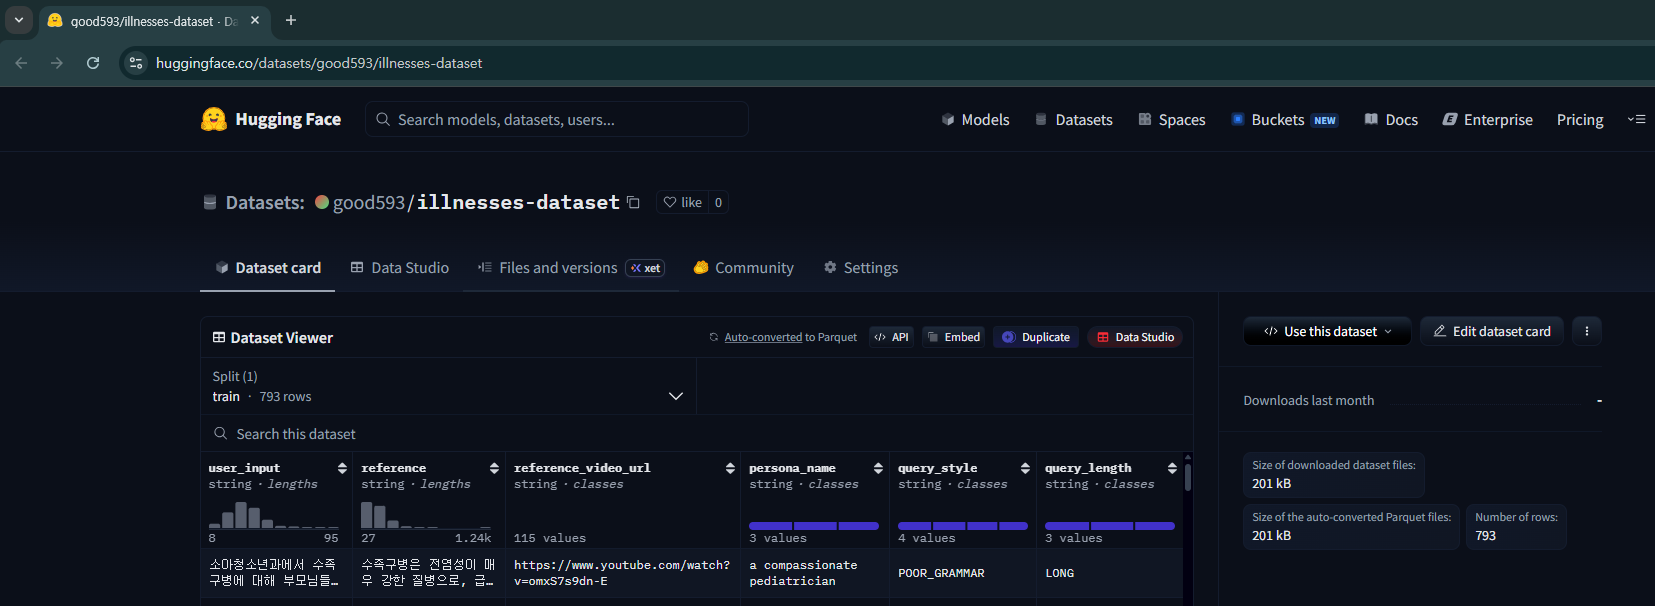